In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from arch import arch_model
import statsmodels
import warnings
from statsmodels.tsa.arima.model import ARIMA

In [2]:
data_2008=pd.read_csv(r'..\..\data\raw\data_2008.csv', index_col=0, parse_dates=True)

In [ ]:
# 1. 데이터(data)에서의 결측치 확인
final_na_counts = data_2008.isna().sum()

print("--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---")
print(final_na_counts)

print("\n--- 데이터 품질 검증 (시작일 및 샘플) ---")
for col in data_2008.columns:
    first_valid = data_2008[col].first_valid_index()
    last_val = data_2008[col].iloc[-1]
    print(f"{col:15} | 시작일: {first_valid.date()} | 최근값: {last_val:10.2f} | 남은 NaN: {data_2008[col].loc[first_valid:].isna().sum()}")

# 전체 행 수 출력
print(f"\n전체 타임라인 행 수: {len(data_2008)}")

--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---
Shanghai Comp        0
KODEX 200          320
TOPIX                2
Brent Crude Oil      0
USD/CNY              0
Gold Spot            0
JPY/KRW              0
USD/KRW              0
NASDAQ               0
KOSDAQ               0
KOSPI 200 Close      0
KOSPI 200 Open       0
KOSPI 200 High       0
KOSPI 200 Low        0
CNY/KRW              0
dtype: int64

--- 데이터 품질 검증 (시작일 및 샘플) ---
Shanghai Comp   | 시작일: 2008-01-02 | 최근값:    4162.88 | 남은 NaN: 0
KODEX 200       | 시작일: 2009-04-17 | 최근값:   94120.00 | 남은 NaN: 0
TOPIX           | 시작일: 2008-01-04 | 최근값:    4131.00 | 남은 NaN: 0
Brent Crude Oil | 시작일: 2008-01-02 | 최근값:      72.48 | 남은 NaN: 0
USD/CNY         | 시작일: 2008-01-02 | 최근값:       6.84 | 남은 NaN: 0
Gold Spot       | 시작일: 2008-01-02 | 최근값:    5230.50 | 남은 NaN: 0
JPY/KRW         | 시작일: 2008-01-02 | 최근값:       9.19 | 남은 NaN: 0
USD/KRW         | 시작일: 2008-01-02 | 최근값:    1432.32 | 남은 NaN: 0
NASDAQ          | 시작일: 2008-01-02 | 최근값:   22668.21 | 남은 NaN: 0


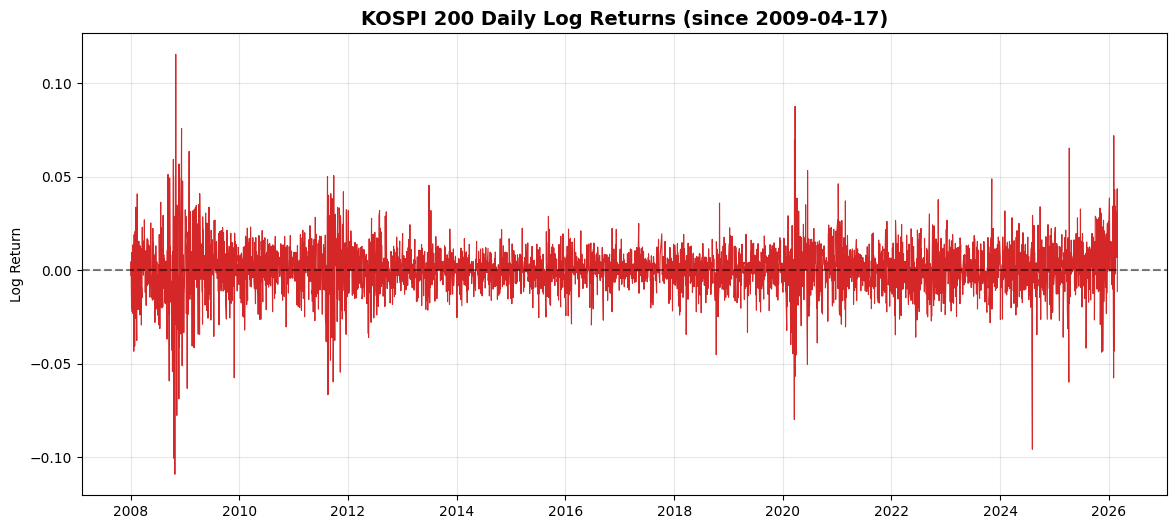

--- KOSPI 200 로그 수익률 기초 통계 ---


count    4428.000000
mean        0.000311
std         0.013063
min        -0.109029
25%        -0.005881
50%         0.000594
75%         0.006923
max         0.115397
Name: KOSPI 200_Log_Return, dtype: float64

In [4]:
# KOSPI 200 로그 수익률 계산: ln(Pt / Pt-1)
# 데이터가 정렬된 상태이므로 shift(1)을 사용하여 계산합니다.
data_2008['KOSPI 200_Log_Return'] = np.log(data_2008['KOSPI 200 Close'] / data_2008['KOSPI 200 Close'].shift(1))

# 시각화
plt.figure(figsize=(14, 6))
plt.plot(data_2008.index, data_2008['KOSPI 200_Log_Return'], color='tab:red', linewidth=0.8)
plt.title('KOSPI 200 Daily Log Returns (since 2009-04-17)', fontsize=14, fontweight='bold')
plt.ylabel('Log Return')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.show()

# 기초 통계량 출력
print("--- KOSPI 200 로그 수익률 기초 통계 ---")
display(data_2008['KOSPI 200_Log_Return'].describe())


In [5]:
#data를 2009-04-17 이후로 자르기
data_2009 = data_2008.loc['2009-04-17':]
data_2009.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4109 entries, 2009-04-17 to 2026-02-27
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Shanghai Comp         4109 non-null   float64
 1   KODEX 200             4109 non-null   float64
 2   TOPIX                 4109 non-null   float64
 3   Brent Crude Oil       4109 non-null   float64
 4   USD/CNY               4109 non-null   float64
 5   Gold Spot             4109 non-null   float64
 6   JPY/KRW               4109 non-null   float64
 7   USD/KRW               4109 non-null   float64
 8   NASDAQ                4109 non-null   float64
 9   KOSDAQ                4109 non-null   float64
 10  KOSPI 200 Close       4109 non-null   float64
 11  KOSPI 200 Open        4109 non-null   float64
 12  KOSPI 200 High        4109 non-null   float64
 13  KOSPI 200 Low         4109 non-null   float64
 14  CNY/KRW               4109 non-null   float64
 15  KOS

In [6]:
#로그 수익률 정상성 검정

from statsmodels.tsa.stattools import adfuller

#로그 수익률 검정을 위해 추출 
full_returns = data_2008['KOSPI 200_Log_Return'].dropna()

# ADF 검정 수행 
#귀무가설 H0: 시계열이 비정상적이다 (Unit Root 존재)
result = adfuller(full_returns)

print('--- KOSPI 200 로그 수익률 ADF 검정 결과 ---')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4e}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.4f}')

if result[1] < 0.05:
    print('\n결과 해석: p-value가 0.05보다 작으므로, 유의수준 5%에서 귀무가설을 기각합니다. 즉, 데이터는 정상성(Stationarity)을 가집니다.')
else:
    print('\n결과 해석: p-value가 0.05보다 크므로, 귀무가설을 기각할 수 없습니다. 데이터가 비정상(Non-stationary)일 가능성이 높습니다.')

--- KOSPI 200 로그 수익률 ADF 검정 결과 ---
ADF Statistic: -67.0027
p-value: 0.0000e+00
Critical Values:
	1%: -3.4318
	5%: -2.8622
	10%: -2.5671

결과 해석: p-value가 0.05보다 작으므로, 유의수준 5%에서 귀무가설을 기각합니다. 즉, 데이터는 정상성(Stationarity)을 가집니다.


In [7]:
#데이터 분할 (학습:검증:테스트 = 5:3:2)
#data_2009로 데이터 분할
#ARIMA 차수 결정을 위해서
n=len(data_2009)

train_end_idx = int(n * 0.5)
valid_end_idx = int(n * 0.8)

train_returns = data_2009.iloc[:train_end_idx]
valid_returns = data_2009.iloc[train_end_idx:valid_end_idx]
test_returns = data_2009.iloc[valid_end_idx:]

print('\n--- 데이터 분할 결과 (5:3:2) ---')
print(f'Train size      : {len(train_returns)}')
print(f'Validation size : {len(valid_returns)}')
print(f'Test size       : {len(test_returns)}')



--- 데이터 분할 결과 (5:3:2) ---
Train size      : 2054
Validation size : 1233
Test size       : 822


In [8]:
#train 에서만 최적 ARIMA 차수 탐색
from statsmodels.tsa.arima.model import ARIMA
import itertools

p=range(0, 3) #AR 차수
d=[0]
q=range(0, 3) # MA 차수

pdq=list(itertools.product(p,d,q))
best_aic = float('inf')
best_order = None
best_model = None

#train 에서만 ARIMA 모델 차수 계산
train_returns_ARIMA = train_returns['KOSPI 200_Log_Return'].dropna()    
for order in pdq:
    try:
        model = ARIMA(train_returns_ARIMA, order=order)
        results = model.fit()

        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
        print(f'ARIMA{order} - AIC: {results.aic:.2f}')

    except Exception as e:
        print(f'ARIMA{order} 실패: {e}')
        continue

print(f'\n[최적 결과] Best ARIMA Order (Train only): {best_order} with AIC: {best_aic:.2f}')

print('\n--- Train 기준 최적 ARIMA 모델 상세 요약 ---')
print(best_model.summary())




c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\dddhs\a

ARIMA(0, 0, 0) - AIC: -12863.75
ARIMA(0, 0, 1) - AIC: -12861.96


c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\dddhs\a

ARIMA(0, 0, 2) - AIC: -12863.43
ARIMA(1, 0, 0) - AIC: -12861.95


c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


...

ARIMA(2, 0, 0) - AIC: -12863.33


c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

ARIMA(2, 0, 1) - AIC: -12861.30


c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dddhs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(2, 0, 2) - AIC: -12860.61

[최적 결과] Best ARIMA Order (Train only): (0, 0, 0) with AIC: -12863.75

--- Train 기준 최적 ARIMA 모델 상세 요약 ---
                                SARIMAX Results                                 
Dep. Variable:     KOSPI 200_Log_Return   No. Observations:                 2054
Model:                            ARIMA   Log Likelihood                6433.875
Date:                  Tue, 07 Apr 2026   AIC                         -12863.749
Time:                          14:45:35   BIC                         -12852.494
Sample:                               0   HQIC                        -12859.622
                                 - 2054                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.244      0.213  

### ARIMA(0,0,0)이라 모델링 안해도됨 (예측 코드는 마크다운으로 기록)

# expanding window 방식: 2008 시작부터 전체 구간 1-step 예측
forecast_values = []
forecast_dates = []

full_returns = data_2008['KOSPI 200_Log_Return'].dropna()

for i in range(0, len(full_returns) - 1):
    train_slice = full_returns.iloc[:i+1]  # 첫 관측치부터 현재 시점까지
    
    try:
        model = ARIMA(train_slice, order=best_order)
        results = model.fit()
        
        forecast = results.forecast(steps=1)  # 다음 1시점 예측
        forecast_values.append(forecast.iloc[0])
        forecast_dates.append(full_returns.index[i+1])
    except Exception:
        # 초기 구간에서 모델 학습이 불안정하면 해당 시점은 스킵
        continue

# 예측 시계열 생성
arima_forecast_series = pd.Series(
    forecast_values,
    index=forecast_dates,
    name='ARIMA_forecast'
)

arima_forecast_series.head(), arima_forecast_series.tail(), len(arima_forecast_series)

# ---------------------------------------------------------
# 4. 원본 data에 예측값 결합
#    - 해당 날짜의 ARIMA_forecast는
#      "직전 시점까지의 실제 데이터로 예측한 그 날짜의 값"
# ---------------------------------------------------------
data_2008_arima = data_2008.copy()
data_2008_arima['ARIMA_forecast']=arima_forecast_series
data.head()

### ARCH 자기상관 검정

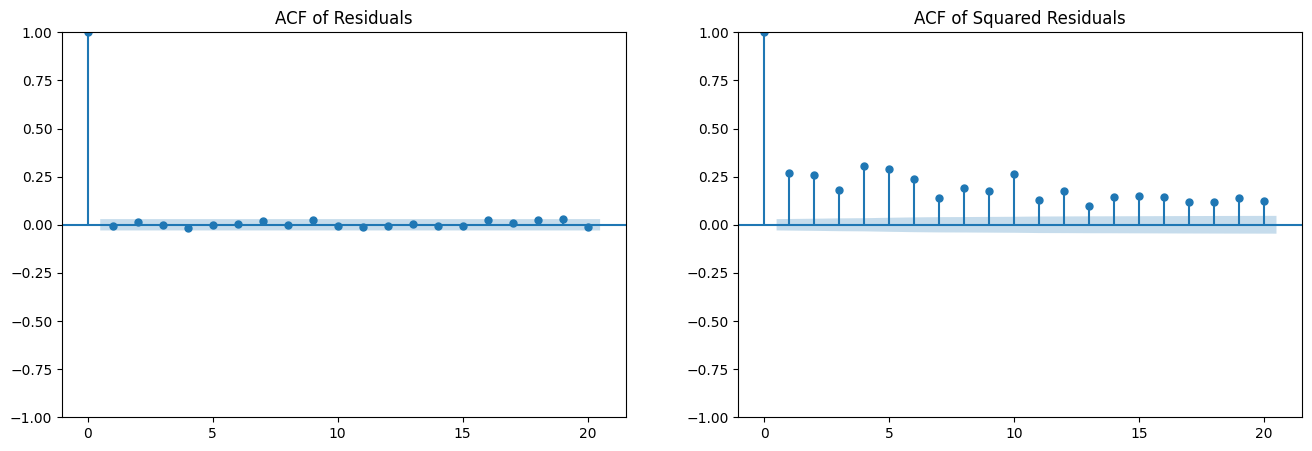

--- ARCH 효과 검정 (Ljung-Box Test on Squared Residuals) ---


,lb_stat,lb_pvalue
10,2515.237077,0.0



결과 해석: p-value(0.0000e+00)가 0.05보다 작으므로 잔차 제곱에 자기상관이 존재합니다.
즉, ARCH 효과가 존재하며 GARCH 모델링을 통한 변동성 분석이 적절합니다.


In [10]:
#GARCH 적용이 적절한지 ARCH 효과 검정

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# 1. 잔차(Residuals) 계산 (ARMA(0,0,0)이므로 수익률에서 평균을 뺀 값)
full_returns = data_2008['KOSPI 200_Log_Return'].dropna()
residuals = full_returns - full_returns.mean()
squared_residuals = residuals**2 #잔차 제곱 계산

# 2. 잔차 제곱의 자기상관 시각화 (ACF)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sm.graphics.tsa.plot_acf(residuals, lags=20, ax=ax[0], title='ACF of Residuals')
sm.graphics.tsa.plot_acf(squared_residuals, lags=20, ax=ax[1], title='ACF of Squared Residuals')
plt.show()

# 3. Ljung-Box 검정을 통한 ARCH 효과(이분산성) 확인
#잔체 제곱에 대해서
lb_test = acorr_ljungbox(squared_residuals, lags=[10], return_df=True)

print("--- ARCH 효과 검정 (Ljung-Box Test on Squared Residuals) ---")
display(lb_test)

if lb_test['lb_pvalue'].iloc[0] < 0.05:
    print(f"\n결과 해석: p-value({lb_test['lb_pvalue'].iloc[0]:.4e})가 0.05보다 작으므로 잔차 제곱에 자기상관이 존재합니다.")
    print("즉, ARCH 효과가 존재하며 GARCH 모델링을 통한 변동성 분석이 적절합니다.")
else:
    print("\n결과 해석: ARCH 효과가 뚜렷하지 않습니다. GARCH 모델링의 실익이 적을 수 있습니다.")

### GARCH 모델링

#### 모델 차수 p,q결정은 train data로 결정 후 1-step ahead는

In [11]:
import itertools
import pandas as pd
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')


#안정성을 위해 100 곱함
#1-step 예측은 2008년 부터 warm-up
full_returns_per = data_2008['KOSPI 200_Log_Return'].dropna() * 100 #퍼센트 단위로 변환
#우리가 실제 분석할구간, GARCH 모델 p,q 탐색 전용 train 데이터
train_returns_garch = train_returns['KOSPI 200_Log_Return']*100

# 1. 탐색할 GARCH 파라미터 범위 설정 (p, q)
p_range = range(1, 4)
q_range = range(1, 4)
pq_combinations = list(itertools.product(p_range, q_range))

best_aic = float('inf')
best_pq = None
best_garch_res = None

print('--- GARCH 최적 모수 그리드 서치 시작 ---')

# 2. 각 조합별 모델 적합 및 AIC 비교
for p, q in pq_combinations:
    try:
        model = arch_model(train_returns_garch, vol='Garch', p=p, q=q, dist='t') #t-분포로 가정
        res = model.fit(disp='off')
        if res.aic < best_aic:
            best_aic = res.aic
            best_pq = (p, q)
            best_garch_res = res
        print(f'GARCH({p}, {q}) - AIC: {res.aic:.2f}')
    except:
        continue

print(f'\n[최적 결과] Best GARCH Order: {best_pq} with AIC: {best_aic:.2f}')

# 3. 최적 모델 상세 요약 및 Alpha+Beta 계산
print('\n--- 최적 GARCH 모델 상세 요약 ---')
print(best_garch_res.summary())

# 최적 모델의 Persistence 계산 (모든 alpha와 beta의 합)
params = best_garch_res.params
persistence = sum([params[k] for k in params.keys() if 'alpha' in k or 'beta' in k])
print(f'\nTotal Persistence (Sum of Alphas and Betas): {persistence:.4f}')

--- GARCH 최적 모수 그리드 서치 시작 ---
GARCH(1, 1) - AIC: 5557.78
GARCH(1, 2) - AIC: 5559.78
GARCH(1, 3) - AIC: 5561.78
GARCH(2, 1) - AIC: 5557.67
GARCH(2, 2) - AIC: 5557.33
GARCH(2, 3) - AIC: 5546.96
GARCH(3, 1) - AIC: 5559.67
GARCH(3, 2) - AIC: 5559.33
GARCH(3, 3) - AIC: 5548.96

[최적 결과] Best GARCH Order: (2, 3) with AIC: 5546.96

--- 최적 GARCH 모델 상세 요약 ---
                        Constant Mean - GARCH Model Results                         
Dep. Variable:         KOSPI 200_Log_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2765.48
Distribution:      Standardized Student's t   AIC:                           5546.96
Method:                  Maximum Likelihood   BIC:                           5591.98
                                              No. Observations:                 2054
Date:                      Tue, Apr 07 2026   Df Resi

--- GARCH 모델 파라미터 및 지속성 분석 ---
Alpha Sum: 0.1391
Beta Sum:  0.8317
Total Persistence (Alpha + Beta): 0.9708

--- 표준화된 잔차 제곱의 Ljung-Box 검정 (ARCH 효과 제거 확인) ---


,lb_stat,lb_pvalue
10,3.935125,0.950226



결과: p-value(0.9502)가 0.05보다 크므로 변동성 구조가 잘 잡혔습니다.


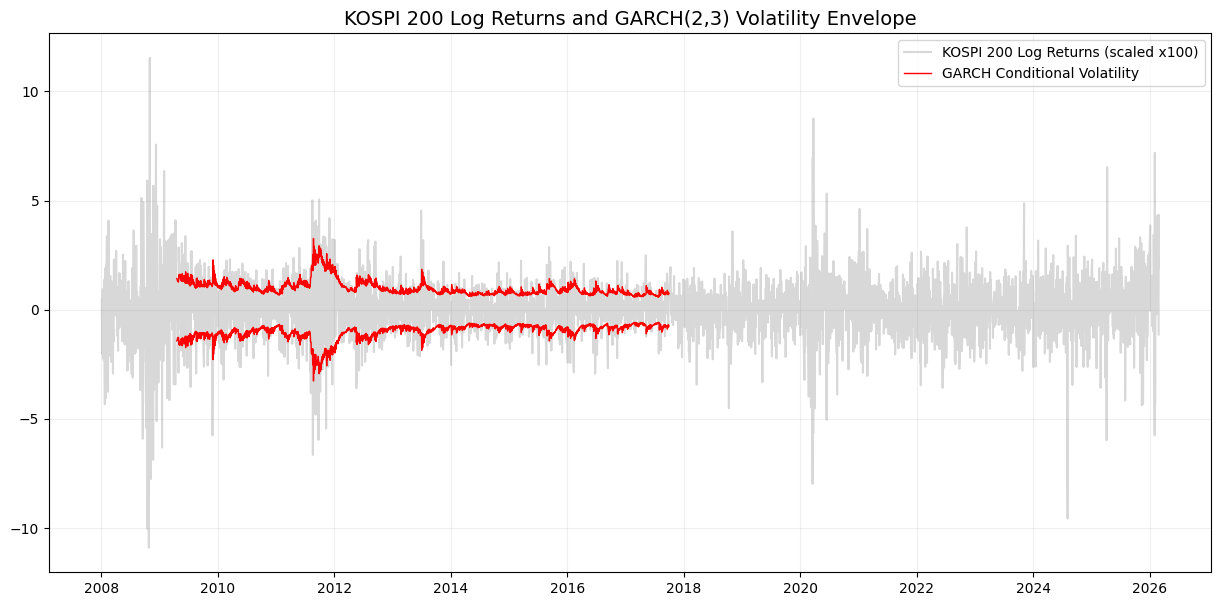

In [13]:
#GARCH 잔차 분석 및 alpha + Beta 값 확인

from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# 1. 최적 모델(best_garch_res)에서 파라미터 및 잔차 추출
# 앞선 셀에서 best_garch_res가 정의되어 있어야 함
params = best_garch_res.params
alpha_sum = sum([params[k] for k in params.keys() if 'alpha' in k])
beta_sum = sum([params[k] for k in params.keys() if 'beta' in k])
persistence = alpha_sum + beta_sum

print(f"--- GARCH 모델 파라미터 및 지속성 분석 ---")
print(f"Alpha Sum: {alpha_sum:.4f}")
print(f"Beta Sum:  {beta_sum:.4f}")
print(f"Total Persistence (Alpha + Beta): {persistence:.4f}")

# 2. 표준화된 잔차(Standardized Residuals) 진단
std_resid = best_garch_res.resid / best_garch_res.conditional_volatility
#귀무가설 H_0: 표준화된 잔차 제곱에 자기상관이 없다 (ARCH 효과 제거 성공)
lb_test_resid = acorr_ljungbox(std_resid**2, lags=[10], return_df=True) #Ljung-Box 검정으로 표준화된 잔차 제곱의 자기상관 확인 

print("\n--- 표준화된 잔차 제곱의 Ljung-Box 검정 (ARCH 효과 제거 확인) ---")
display(lb_test_resid)

if lb_test_resid['lb_pvalue'].iloc[0] > 0.05:
    print(f"\n결과: p-value({lb_test_resid['lb_pvalue'].iloc[0]:.4f})가 0.05보다 크므로 변동성 구조가 잘 잡혔습니다.")
else:
    print("\n결과: 잔차에 여전히 자기상관이 남아있습니다.")

# 3. 원본 로그 수익률 vs GARCH 변동성 플랏
plt.figure(figsize=(15, 7))
plt.plot(full_returns_per, color='gray', alpha=0.3, label='KOSPI 200 Log Returns (scaled x100)')
plt.plot(best_garch_res.conditional_volatility, color='red', linewidth=1, label='GARCH Conditional Volatility')
plt.plot(-best_garch_res.conditional_volatility, color='red', linewidth=1)
plt.title(f'KOSPI 200 Log Returns and GARCH({best_pq[0]},{best_pq[1]}) Volatility Envelope', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

#### GARCH forcast

In [14]:
# =========================================================
# GARCH one-step ahead forecast feature 생성
# - best_p, best_q는 train에서 이미 선택된 상태
# - full_returns는 2008년부터의 warm-up 포함 전체 수익률(×100)
# - 오늘 row에 "내일 예측값"을 저장
# =========================================================

import numpy as np
import pandas as pd
from scipy.stats import t

best_p, best_q = best_pq #미리 설정한 차수 

full_returns_per = data_2008['KOSPI 200_Log_Return'].dropna() * 100

#초기 학습창 설정 250정도
initial_window=250
if len(full_returns_per) <= initial_window + 1:
    raise ValueError("full_returns 길이가 initial_window보다 너무 짧습니다.")

garch_mu_t1_list = []
garch_sigma_t1_list = []
garch_var5_t1_list = []
garch_var1_t1_list = []
feature_dates = []

print('--- GARCH One-Step Ahead Forecast 시작 ---')

for i in range(initial_window, len(full_returns_per)):

    current_date = full_returns_per.index[i]

    try:
        # current_date까지의 실제 데이터만 사용
        past_returns = full_returns_per.iloc[:i+1].dropna()

        model = arch_model(
            past_returns,
            mean='Constant',
            vol='Garch',
            p=best_p,
            q=best_q,
            dist='t'
        )
        res = model.fit(disp='off')

        # 1-step ahead forecast
        fcast = res.forecast(horizon=1, reindex=False)

        mu_t1 = fcast.mean.iloc[-1, 0]
        var_t1 = fcast.variance.iloc[-1, 0]
        sigma_t1 = np.sqrt(var_t1)

        # t-분포 자유도 추출
        nu = res.params.get('nu', np.nan)

        # arch의 standardized t 분포 quantile 보정
        if np.isfinite(nu) and nu > 2:
            q05 = t.ppf(0.05, df=nu) * np.sqrt((nu - 2) / nu)
        else:
            q05 = np.nan

        # return 기준 VaR 예측값
        var5_t1 = mu_t1 + sigma_t1 * q05

        # 오늘 row의 feature로 저장
        garch_mu_t1_list.append(mu_t1)
        garch_sigma_t1_list.append(sigma_t1)
        garch_var5_t1_list.append(var5_t1)
        feature_dates.append(current_date)

    except Exception as e:
        print(f'{current_date} forecast 실패: {e}')
        garch_mu_t1_list.append(np.nan)
        garch_sigma_t1_list.append(np.nan)
        garch_var5_t1_list.append(np.nan)
        feature_dates.append(current_date)

# feature DataFrame 생성
garch_feature_df = pd.DataFrame({
    'GARCH_mu_t1': garch_mu_t1_list,
    'GARCH_sigma_t1': garch_sigma_t1_list,
    'GARCH_VaR_5_t1': garch_var5_t1_list
}, index=feature_dates)

# 원본 데이터에 결합
# 원본 데이터에 결합 (기존 동일 컬럼 제거 후 다시 붙이기)
cols_to_drop = ['GARCH_mu_t1', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1']
data_2008_garch = data_2008.copy()
data_2008_garch = data_2008_garch.drop(columns=cols_to_drop, errors='ignore')
data_2008_garch = data_2008_garch.join(garch_feature_df, how='left')

print('\n--- 생성된 GARCH one-step forecast feature 일부 확인 ---')
display(
    data_2008_garch.loc[feature_dates, [
        'KOSPI 200_Log_Return',
        'GARCH_mu_t1',
        'GARCH_sigma_t1',
        'GARCH_VaR_5_t1'
    ]].head(5)
)

--- GARCH One-Step Ahead Forecast 시작 ---

--- 생성된 GARCH one-step forecast feature 일부 확인 ---


,KOSPI 200_Log_Return,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1
Date,,,,
2009-01-07,0.028731,-0.114355,2.183001,-3.688734
2009-01-08,-0.022563,-0.120057,2.697223,-4.537479
2009-01-09,-0.023019,-0.122991,2.154206,-3.651292
2009-01-12,-0.020710,-0.128320,2.336690,-3.956122
2009-01-13,0.009491,-0.126168,2.354590,-3.982796


In [15]:
data_2008_garch.tail(10)

,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,USD/CNY,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,KOSPI 200 Open,KOSPI 200 High,KOSPI 200 Low,CNY/KRW,KOSPI 200_Log_Return,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1
Date,,,,,,,,,,,,,,,,,,,
2026-02-11,4131.984863,79115.0,4047.0,69.400002,6.9106,5071.600098,9.420313,1455.329956,23066.470703,1114.869995,788.750000,778.250000,792.229980,772.409973,210.593858,0.010182,0.047973,2.603578,-4.110101
2026-02-12,4134.018066,81975.0,4077.0,67.519997,6.9125,4923.700195,9.422499,1444.189941,22597.150391,1125.989990,816.280029,800.150024,816.280029,796.359985,208.924407,0.034308,0.048070,2.637959,-4.165282
2026-02-13,4082.072998,81860.0,4012.0,67.750000,6.9001,5022.000000,9.426427,1440.900024,22546.669922,1106.079956,814.590027,815.969971,827.140015,811.159973,208.823057,-0.002073,0.048075,2.659969,-4.200167
2026-02-19,4082.072998,84390.0,4046.0,71.660004,6.9080,4975.899902,9.309102,1440.160034,22682.730469,1160.709961,840.239990,836.119995,841.950012,830.570007,208.477133,0.031003,0.048155,2.498797,-3.942967
2026-02-20,4082.072998,86300.0,4001.0,71.760002,6.9081,5059.299805,9.330300,1447.750000,22886.070312,1154.000000,859.590027,842.559998,860.219971,839.979980,209.572816,0.022768,0.048244,2.620355,-4.137225
2026-02-23,4082.072998,86940.0,4001.0,71.489998,6.9080,5204.700195,9.356865,1443.439941,22627.269531,1151.989990,865.489990,874.929993,879.849976,856.900024,208.951932,0.006840,0.048309,2.482679,-3.917079
2026-02-24,4117.409180,89085.0,4011.0,70.769997,6.9080,5155.799805,9.324820,1442.199951,22863.679688,1165.000000,886.880005,866.440002,886.950012,855.130005,208.772431,0.024414,0.048395,2.374369,-3.744202
2026-02-25,4147.229980,90890.0,4045.0,70.849998,6.8831,5206.399902,9.237456,1439.989990,23152.080078,1165.250000,903.830017,895.380005,913.669983,888.960022,209.206605,0.018932,0.048487,2.474667,-3.904428
2026-02-26,4146.630859,95025.0,4078.0,70.750000,6.8692,5176.500000,9.134690,1426.930054,22878.380859,1188.150024,944.020020,910.729980,945.169983,908.119995,207.728703,0.043506,0.048514,2.540873,-4.010446


### GJR-GARCH 모델링

In [16]:

# =========================================================
# GJR-GARCH(p,1,q) 차수 선택(train_returns_garch) + 
# full_returns_per 기반 1-step ahead feature 생성
# =========================================================

train_returns_gjr = train_returns['KOSPI 200_Log_Return']*100

# 1) train 데이터로 GJR-GARCH 차수(p,q) 선택 (o=1 고정)
gjr_best_aic = float('inf')
gjr_best_order = None
gjr_best_res = None

for p in range(1, 4):
    for q in range(1, 4):
        try:
            gjr_model = arch_model(
                train_returns_gjr.dropna(),
                mean='Constant',
                vol='GARCH',
                p=p,
                o=1,   # GJR 비대칭 항
                q=q,
                dist='t'
            )
            gjr_res = gjr_model.fit(disp='off')

            if gjr_res.aic < gjr_best_aic:
                gjr_best_aic = gjr_res.aic
                gjr_best_order = (p, 1, q)
                gjr_best_res = gjr_res

            print(f"GJR-GARCH({p},1,{q}) - AIC: {gjr_res.aic:.2f}")
        except Exception as e:
            print(f"GJR-GARCH({p},1,{q}) 실패: {e}")
            continue

print(f"\n[최적 결과] Best GJR-GARCH Order: {gjr_best_order}, AIC: {gjr_best_aic:.2f}")
print(gjr_best_res.summary())


GJR-GARCH(1,1,1) - AIC: 5517.26
GJR-GARCH(1,1,2) - AIC: 5519.26
GJR-GARCH(1,1,3) - AIC: 5520.87
GJR-GARCH(2,1,1) - AIC: 5519.26
GJR-GARCH(2,1,2) - AIC: 5521.26
GJR-GARCH(2,1,3) - AIC: 5522.87
GJR-GARCH(3,1,1) - AIC: 5521.26
GJR-GARCH(3,1,2) - AIC: 5523.26
GJR-GARCH(3,1,3) - AIC: 5524.87

[최적 결과] Best GJR-GARCH Order: (1, 1, 1), AIC: 5517.26
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:         KOSPI 200_Log_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -2752.63
Distribution:      Standardized Student's t   AIC:                           5517.26
Method:                  Maximum Likelihood   BIC:                           5551.03
                                              No. Observations:                 2054
Date:                      Tue, Apr 07 2026   Df Residuals:   

In [17]:
# 2) full_returns_per로 expanding window 1-step ahead 예측
gjr_p, gjr_o, gjr_q = gjr_best_order

gjr_mu_t1_list = []
gjr_sigma_t1_list = []
gjr_var5_t1_list = []
gjr_feature_dates = []

initial_window=250

for i in range(initial_window, len(full_returns_per)):
    current_date = full_returns_per.index[i]
    past_returns = full_returns_per.iloc[:i+1].dropna()

    try:
        model = arch_model(
            past_returns,
            mean='Constant',
            vol='GARCH',
            p=gjr_p,
            o=gjr_o,
            q=gjr_q,
            dist='t'
        )
        res = model.fit(disp='off')
        fcast = res.forecast(horizon=1, reindex=False)

        mu_t1 = fcast.mean.iloc[-1, 0]
        var_t1 = fcast.variance.iloc[-1, 0]
        sigma_t1 = np.sqrt(var_t1)

        nu = res.params.get('nu', np.nan)
        if np.isfinite(nu) and nu > 2:
            q05 = t.ppf(0.05, df=nu) * np.sqrt((nu - 2) / nu)
        else:
            q05 = np.nan

        var5_t1 = mu_t1 + sigma_t1 * q05

        gjr_mu_t1_list.append(mu_t1)
        gjr_sigma_t1_list.append(sigma_t1)
        gjr_var5_t1_list.append(var5_t1)
        gjr_feature_dates.append(current_date)

    except Exception:
        gjr_mu_t1_list.append(np.nan)
        gjr_sigma_t1_list.append(np.nan)
        gjr_var5_t1_list.append(np.nan)
        gjr_feature_dates.append(current_date)

# 3) feature DataFrame 생성 및 원본 결합
gjr_feature_df = pd.DataFrame(
    {
        'GJR_mu_t1': gjr_mu_t1_list,
        'GJR_sigma_t1': gjr_sigma_t1_list,
        'GJR_VaR_5_t1': gjr_var5_t1_list
    },
    index=gjr_feature_dates
)

data_2008_gjr = data_2008_garch.copy()
data_2008_gjr = data_2008_gjr.drop(columns=['GJR_mu_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1'], errors='ignore')
data_2008_gjr = data_2008_gjr.join(gjr_feature_df, how='left')

display(data_2008_gjr[['KOSPI 200_Log_Return', 'GJR_mu_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1']].tail())

,KOSPI 200_Log_Return,GJR_mu_t1,GJR_sigma_t1,GJR_VaR_5_t1
Date,,,,
2026-02-23,0.006840,0.034165,2.097620,-3.323919
2026-02-24,0.024414,0.034274,2.052966,-3.252566
2026-02-25,0.018932,0.034380,1.992347,-3.155541
2026-02-26,0.043506,0.034501,2.061917,-3.266903
2026-02-27,-0.011378,0.034422,2.012294,-3.187511


In [21]:
data_2008_gjr.head()

,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,USD/CNY,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,...,KOSPI 200 High,KOSPI 200 Low,CNY/KRW,KOSPI 200_Log_Return,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1,GJR_mu_t1,GJR_sigma_t1,GJR_VaR_5_t1
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-02,5272.813965,NaN,NaN,97.839996,7.2852,857.000000,8.5750,937.119995,2609.629883,707.119995,...,240.649994,235.020004,128.633391,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-03,5319.860840,NaN,NaN,97.599998,7.2629,866.400024,8.5379,935.150024,2602.679932,714.000000,...,235.639999,230.860001,128.757114,-0.002681,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-04,5361.574219,NaN,1431.040039,96.790001,7.2630,863.099976,8.6477,939.530029,2504.649902,719.250000,...,236.589996,230.410004,129.358396,0.004677,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-07,5393.342773,NaN,1411.410034,94.389999,7.2578,859.599976,8.5970,939.270020,2499.459961,711.770020,...,232.419998,229.089996,129.415251,-0.020439,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-08,5386.530762,NaN,1421.959961,95.540001,7.2535,878.000000,8.6145,938.890015,2440.510010,709.309998,...,232.320007,229.190002,129.439583,-0.002861,NaN,NaN,NaN,NaN,NaN,NaN


### GARCH VAR 시각화

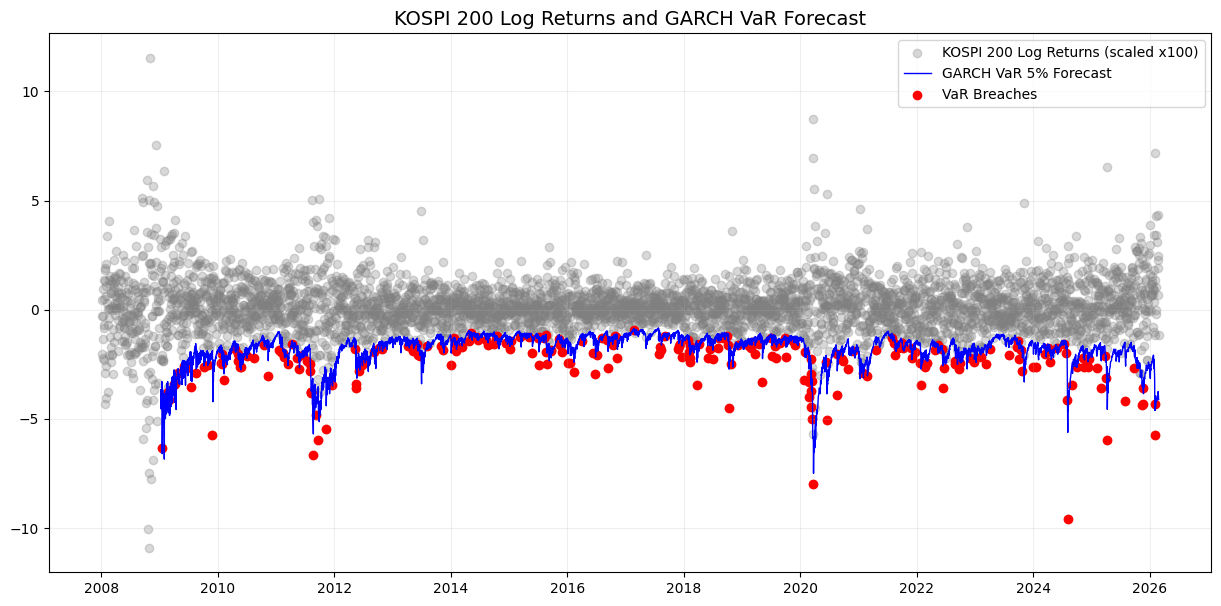

In [19]:
#실제 수익률과 GARCH로 모델링한 VaR scatter 및 파란선으로 시각화
#VaR을 초과한 지점은 빨간색으로 강조 표시
plt.figure(figsize=(15, 7))
plt.scatter(
    data_2008_garch.index,
    data_2008_garch['KOSPI 200_Log_Return'] * 100,
    color='gray',
    alpha=0.3,
    label='KOSPI 200 Log Returns (scaled x100)'
)
plt.plot(
    data_2008_garch.index,
    data_2008_garch['GARCH_VaR_5_t1'],
    color='blue',
    linewidth=1,
    label='GARCH VaR 5% Forecast'
)
# VaR 초과 지점 강조
breaches = data_2008_garch['KOSPI 200_Log_Return'] *100 < data_2008_garch['GARCH_VaR_5_t1']
plt.scatter(
    data_2008_garch.index[breaches],
    data_2008_garch.loc[breaches, 'KOSPI 200_Log_Return'] * 100,
    color='red',
    label='VaR Breaches'
)
plt.title('KOSPI 200 Log Returns and GARCH VaR Forecast', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()



### gjr-GARCH VaR 시각화

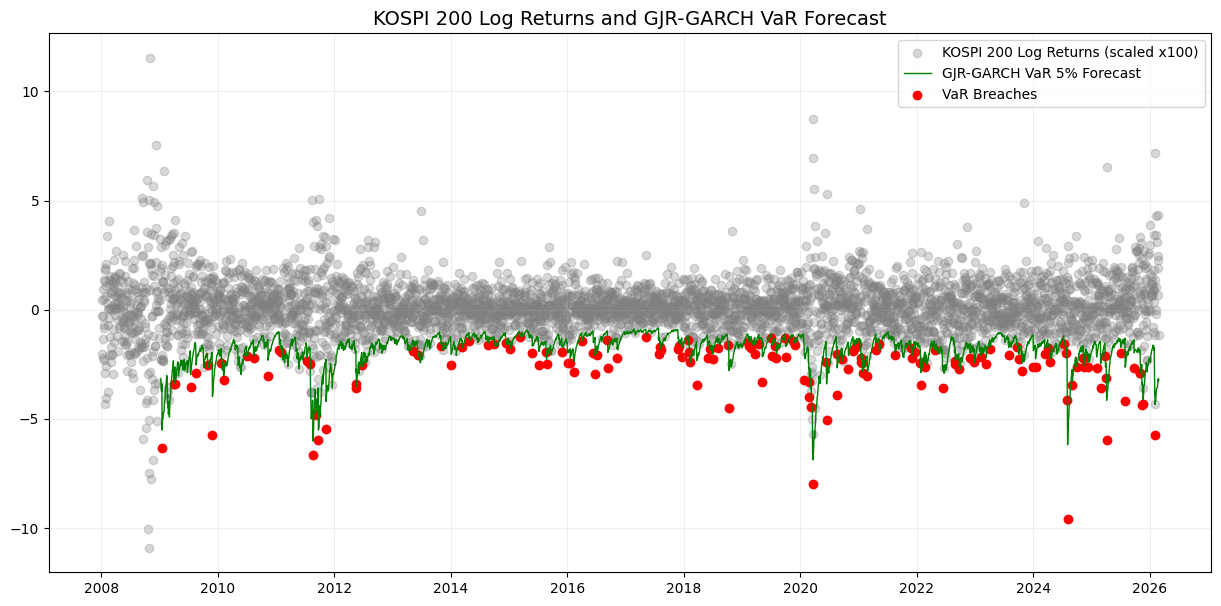

In [20]:
#gjr-garch 모델링한 VaR 시각화
plt.figure(figsize=(15, 7))
plt.scatter(
    data_2008_gjr.index,
    data_2008_gjr['KOSPI 200_Log_Return'] * 100,
    color='gray',
    alpha=0.3,
    label='KOSPI 200 Log Returns (scaled x100)'
)
plt.plot(
    data_2008_gjr.index,
    data_2008_gjr['GJR_VaR_5_t1'],
    color='green',
    linewidth=1,
    label='GJR-GARCH VaR 5% Forecast'
)
breaches_gjr = data_2008_gjr['KOSPI 200_Log_Return'] *100 < data_2008_gjr['GJR_VaR_5_t1']
plt.scatter(
    data_2008_gjr.index[breaches_gjr],
    data_2008_gjr.loc[breaches_gjr, 'KOSPI 200_Log_Return'] * 100,
    color='red',
    label='VaR Breaches'
)
plt.title('KOSPI 200 Log Returns and GJR-GARCH VaR Forecast', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


In [33]:
data_2009_gjr = data_2008_gjr.loc['2009-04-17':]
data_2009_gjr['return(%)'] = data_2009_gjr['KOSPI 200_Log_Return']*100
data_2009_gjr.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4109 entries, 2009-04-17 to 2026-02-27
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Shanghai Comp         4109 non-null   float64
 1   KODEX 200             4109 non-null   float64
 2   TOPIX                 4109 non-null   float64
 3   Brent Crude Oil       4109 non-null   float64
 4   USD/CNY               4109 non-null   float64
 5   Gold Spot             4109 non-null   float64
 6   JPY/KRW               4109 non-null   float64
 7   USD/KRW               4109 non-null   float64
 8   NASDAQ                4109 non-null   float64
 9   KOSDAQ                4109 non-null   float64
 10  KOSPI 200 Close       4109 non-null   float64
 11  KOSPI 200 Open        4109 non-null   float64
 12  KOSPI 200 High        4109 non-null   float64
 13  KOSPI 200 Low         4109 non-null   float64
 14  CNY/KRW               4109 non-null   float64
 15  KOS

### VaR 분류하기

In [34]:
#train/validation/test를 5:3:2로 나누기
total_len = len(data_2009_gjr)
train_end = int(total_len * 0.5)
val_end = int(total_len * 0.8)
train_data = data_2009_gjr.iloc[:train_end]
val_data = data_2009_gjr.iloc[train_end:val_end]
test_data = data_2009_gjr.iloc[val_end:]


In [35]:
#train set에서 VaR보다 작은 값중에 가장 큰 것을 threshold로 설정
threshold =train_data[train_data['return(%)'] <train_data['GJR_VaR_5_t1']]['return(%)'].max()
threshold

-1.23145016816627

In [36]:
train_data.tail()

,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,USD/CNY,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,...,KOSPI 200 Low,CNY/KRW,KOSPI 200_Log_Return,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1,GJR_mu_t1,GJR_sigma_t1,GJR_VaR_5_t1,return(%)
Date,,,,,,,,,,,,,,,,,,,,,
2017-09-25,3341.549072,31645.0,1709.0,59.020000,6.6046,1306.800049,10.083,1132.109985,6370.589844,642.039978,...,315.299988,171.412348,-0.005830,0.042134,0.798782,-1.232443,0.022290,0.704827,-1.107176,-0.583002
2017-09-26,3343.583008,31485.0,1708.0,58.439999,6.6205,1297.000000,10.143,1133.819946,6380.160156,642.400024,...,313.679993,171.258958,-0.006691,0.041605,0.724534,-1.114637,0.021660,0.728605,-1.146068,-0.669106
2017-09-27,3345.271973,31420.0,1714.0,57.900002,6.6396,1283.400024,10.112,1136.719971,6453.259766,649.239990,...,313.320007,171.203085,-0.001497,0.041405,0.728533,-1.121110,0.021496,0.715313,-1.124832,-0.149656
2017-09-28,3339.642090,31455.0,1723.0,57.410000,6.6405,1285.500000,10.142,1145.280029,6453.450195,648.090027,...,312.880005,172.468943,0.000096,0.041374,0.732488,-1.127310,0.021484,0.700291,-1.100642,0.009559
2017-09-29,3348.943115,31700.0,1722.0,57.540001,6.6650,1281.500000,10.180,1145.939941,6495.959961,652.820007,...,314.600006,171.933976,0.007681,0.041929,0.687883,-1.055715,0.022103,0.686573,-1.078168,0.768106


In [37]:
#전체 데이터인 data_2009_gjr에서 threshold를 사용하여 high risk / low risk 구분 
data_2009_gjr['Risk_Label'] = np.where(data_2009_gjr['return(%)'] < threshold, 'High Risk', 'Low Risk')


In [38]:
total_len = len(data_2009_gjr)
train_end = int(total_len * 0.5)
val_end = int(total_len * 0.8)
train_data_gjr = data_2009_gjr.iloc[:train_end]
val_data_gjr = data_2009_gjr.iloc[train_end:val_end]
test_data_gjr = data_2009_gjr.iloc[val_end:]

#각 구간의 risk 개수와 비율 출력
print("--- Train Set Risk Distribution ---")    
print(train_data_gjr['Risk_Label'].value_counts())
print("\n--- Validation Set Risk Distribution ---")
print(val_data_gjr['Risk_Label'].value_counts())
print("\n--- Test Set Risk Distribution ---")
print(test_data_gjr['Risk_Label'].value_counts())


--- Train Set Risk Distribution ---
Risk_Label
Low Risk     1859
High Risk     195
Name: count, dtype: int64

--- Validation Set Risk Distribution ---
Risk_Label
Low Risk     1071
High Risk     162
Name: count, dtype: int64

--- Test Set Risk Distribution ---
Risk_Label
Low Risk     730
High Risk     92
Name: count, dtype: int64


In [39]:
data_2009_gjr.drop(columns=['GJR_mu_t1'], inplace=True)
data_2009_gjr.drop(columns=['USD/CNY'], inplace=True)
data_2009_gjr.head()

,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,...,KOSPI 200 Low,CNY/KRW,KOSPI 200_Log_Return,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1,GJR_sigma_t1,GJR_VaR_5_t1,return(%),Risk_Label
Date,,,,,,,,,,,,,,,,,,,,,
2009-04-17,2503.935059,17370.0,875.0,51.959999,867.400024,13.371,1325.800049,1673.069946,483.799988,171.330002,...,169.710007,194.324755,-0.002332,-0.077605,1.847381,-3.088512,1.608928,-2.736404,-0.233192,Low Risk
2009-04-20,2557.456055,17480.0,876.0,51.959999,887.000000,13.536,1327.500000,1608.209961,491.940002,172.300003,...,169.039993,194.562510,0.005646,-0.074431,1.907081,-3.181876,1.553372,-2.641002,0.564563,Low Risk
2009-04-21,2535.827881,17480.0,855.0,51.959999,882.099976,13.727,1354.300049,1643.849976,497.190002,171.960007,...,167.660004,198.668030,-0.001975,-0.073820,1.796955,-3.000601,1.500503,-2.553085,-0.197523,Low Risk
2009-04-22,2461.345947,17715.0,856.0,51.959999,891.799988,13.726,1346.599976,1646.119995,509.899994,174.399994,...,171.860001,197.463154,0.014090,-0.067794,1.656372,-2.766048,1.453282,-2.469281,1.408955,Low Risk
2009-04-23,2463.954102,17895.0,862.0,51.959999,905.900024,13.618,1333.599976,1652.209961,514.090027,176.139999,...,173.899994,195.562586,0.009928,-0.062765,1.791522,-2.981231,1.406416,-2.386329,0.992765,Low Risk


### bind하기 편하게 하기위해서 모델링 파생변수들만 뽑기

In [40]:
#GARCH_mu_t1 부터 마지막 컬럼까지 data_2009_gjr의 feature로 설정
feature_cols = data_2009_gjr.columns[data_2009_gjr.columns.get_loc('GARCH_mu_t1'):]
print("Feature columns:", feature_cols.tolist())

Feature columns: ['GARCH_mu_t1', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'return(%)', 'Risk_Label']


In [41]:
data_2009_gjr=data_2009_gjr[feature_cols]
data_2009_gjr.head()

,GARCH_mu_t1,GARCH_sigma_t1,GARCH_VaR_5_t1,GJR_sigma_t1,GJR_VaR_5_t1,return(%),Risk_Label
Date,,,,,,,
2009-04-17,-0.077605,1.847381,-3.088512,1.608928,-2.736404,-0.233192,Low Risk
2009-04-20,-0.074431,1.907081,-3.181876,1.553372,-2.641002,0.564563,Low Risk
2009-04-21,-0.073820,1.796955,-3.000601,1.500503,-2.553085,-0.197523,Low Risk
2009-04-22,-0.067794,1.656372,-2.766048,1.453282,-2.469281,1.408955,Low Risk
2009-04-23,-0.062765,1.791522,-2.981231,1.406416,-2.386329,0.992765,Low Risk


In [43]:
data_2009_gjr.to_csv(r'..\..\data\processed\data_one_step_GARCH_GJR-GARCH_VaR_Label.csv', index=True)